# SHOW ME your WORK 💪

# Problem statement
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient

# Data Collection
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [39]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
# read the data
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("susant4learning/holiday-package-purchase-prediction")
print("Path to dataset files:", path)

# show files inside dataset
print(os.listdir(path))

# read the csv file
df = pd.read_csv(os.path.join(path, "Travel.csv"))

# show first rows
df.head()

Using Colab cache for faster access to the 'holiday-package-purchase-prediction' dataset.
Path to dataset files: /kaggle/input/holiday-package-purchase-prediction
['Travel.csv']


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning

In [6]:
df.shape

(4888, 20)

In [7]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [14]:
miss_tab = pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'missing_values_percentage': df.isnull().sum() / df.shape[0] * 100,
    'data_type': df.dtypes
}).sort_values(by='missing_values', ascending=False)
miss_tab[miss_tab['missing_values'] > 0]

,missing_values,missing_values_percentage,data_type
DurationOfPitch,251,5.135025,float64
MonthlyIncome,233,4.766776,float64
Age,226,4.623568,float64
NumberOfTrips,140,2.864157,float64
NumberOfChildrenVisiting,66,1.350245,float64
NumberOfFollowups,45,0.920622,float64
PreferredPropertyStar,26,0.531915,float64
TypeofContact,25,0.511457,object


In [20]:
# drop nan in cat
df.dropna(subset=['TypeofContact'], inplace=True)

In [21]:
# columns with large
mis_num_col = ['DurationOfPitch','MonthlyIncome','Age','NumberOfTrips','NumberOfChildrenVisiting','NumberOfFollowups','PreferredPropertyStar']
for col in mis_num_col:
    df[col].fillna(df[col].median(), inplace=True)

In [22]:
#final check
df.isnull().sum().sum()

np.int64(0)

## Feature Engineering & Encoding

In [25]:
num_col = df.select_dtypes(include=np.number).columns
cat_col = df.select_dtypes(exclude=np.number).columns
print(f'numerical columns: {num_col}')
print(f'categorical columns: {cat_col}')

numerical columns: Index(['CustomerID', 'ProdTaken', 'Age', 'CityTier', 'DurationOfPitch',
       'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')
categorical columns: Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')


In [27]:
#encode cat col
le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])

In [29]:
# yearly income
df['YearlyIncome'] = df['MonthlyIncome'] * 12

In [30]:
#YearlyIncome_per_person
df['YearlyIncome_per_person'] = df['YearlyIncome'] / df['NumberOfPersonVisiting']

# splitting

In [32]:
y = df['ProdTaken']
X = df.drop(['ProdTaken','CustomerID'], axis=1)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Build a classification model using support vector machine. Use standalone model as well as Bagging model and check if you see any difference in the performance.

In [34]:
# scale for svm
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [36]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [51]:
alone_svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("Standalone SVM Accuracy:",alone_svm_accuracy )
print(classification_report(y_test, y_pred_svm))

Standalone SVM Accuracy: 0.8499486125385406
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       774
           1       0.85      0.32      0.47       199

    accuracy                           0.85       973
   macro avg       0.85      0.65      0.69       973
weighted avg       0.85      0.85      0.82       973



    Bagging + SVM

In [52]:
bagging_svm = BaggingClassifier(
    estimator=SVC(kernel='rbf', probability=True, random_state=42),
    n_estimators=10,random_state=42,n_jobs=-1)

bagging_svm.fit(X_train_scaled, y_train)

y_pred_bagging = bagging_svm.predict(X_test_scaled)

#score
bagging_svm_accuracy = accuracy_score(y_test, y_pred_bagging)
print("Bagging SVM Accuracy:", bagging_svm_accuracy)
print(classification_report(y_test, y_pred_bagging))

Bagging SVM Accuracy: 0.8787255909558068
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       774
           1       0.88      0.47      0.61       199

    accuracy                           0.88       973
   macro avg       0.88      0.73      0.77       973
weighted avg       0.88      0.88      0.86       973



#### Now use decision tree classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [43]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [53]:
y_pred_dt = dt_model.predict(X_test)

alone_dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Standalone Decision Tree Accuracy:", alone_dt_accuracy)
print(classification_report(y_test, y_pred_dt))

Standalone Decision Tree Accuracy: 0.9157245632065776
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       774
           1       0.80      0.78      0.79       199

    accuracy                           0.92       973
   macro avg       0.87      0.86      0.87       973
weighted avg       0.91      0.92      0.92       973



In [54]:
bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,random_state=42,n_jobs=-1)

bagging_dt.fit(X_train, y_train)

y_pred_bagging_dt = bagging_dt.predict(X_test)

#score
bagging_dt_accuracy = accuracy_score(y_test, y_pred_bagging_dt)
print("Bagging Decision Tree Accuracy:", bagging_dt_accuracy)
print(classification_report(y_test, y_pred_bagging_dt))

Bagging Decision Tree Accuracy: 0.9270298047276464
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       774
           1       0.92      0.70      0.80       199

    accuracy                           0.93       973
   macro avg       0.92      0.84      0.88       973
weighted avg       0.93      0.93      0.92       973



#### then use random forest classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [47]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [55]:
y_pred_rf = rf_model.predict(X_test)

alone_rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Standalone Random Forest Accuracy:", alone_rf_accuracy)
print(classification_report(y_test, y_pred_rf))

Standalone Random Forest Accuracy: 0.9126413155190134
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       774
           1       0.93      0.62      0.74       199

    accuracy                           0.91       973
   macro avg       0.92      0.80      0.85       973
weighted avg       0.91      0.91      0.91       973



In [56]:
bagging_rf = BaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_estimators=10,random_state=42,n_jobs=-1)

bagging_rf.fit(X_train, y_train)

y_pred_bagging_rf = bagging_rf.predict(X_test)

#score
bagging_rf_accuracy = accuracy_score(y_test, y_pred_bagging_rf)
print("Bagging + Random Forest Accuracy:", bagging_rf_accuracy)
print(classification_report(y_test, y_pred_bagging_rf))

Bagging + Random Forest Accuracy: 0.8776978417266187
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       774
           1       0.93      0.44      0.59       199

    accuracy                           0.88       973
   macro avg       0.90      0.71      0.76       973
weighted avg       0.88      0.88      0.86       973



#### Comparing performance of them to figure out where it makes most sense to use bagging and why. What conditions bagging works the best.

In [57]:
#visual diff
models = ['SVM', 'Decision Tree', 'Random Forest']
alone_accuracies = [alone_svm_accuracy, alone_dt_accuracy, alone_rf_accuracy]
bagging_accuracies = [bagging_svm_accuracy, bagging_dt_accuracy, bagging_rf_accuracy]

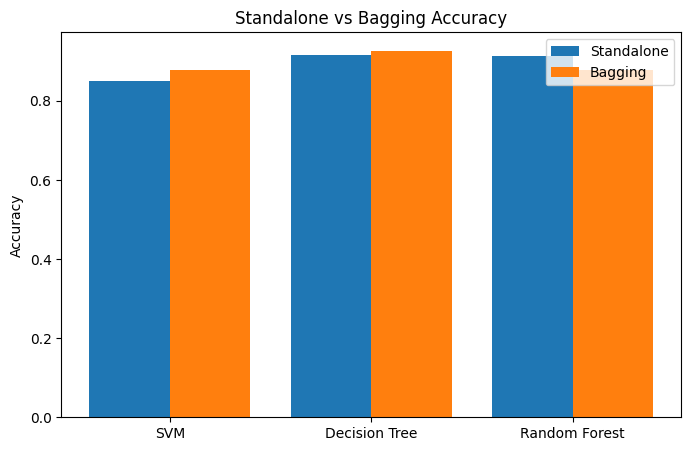

In [59]:
x = range(len(models))

# barplot
plt.figure(figsize=(8,5))
plt.bar(x, alone_accuracies, width=0.4, label='Standalone', align='center')
plt.bar([i + 0.4 for i in x], bagging_accuracies, width=0.4, label='Bagging', align='center')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel('Accuracy')
plt.title('Standalone vs Bagging Accuracy')
plt.legend()
plt.show()